# Olympics 2008 Medalists: Data Cleaning and Visualization

## Objective
This notebook applies **tidy data principles** to the `olympics_08_medalists.csv` dataset. The goal is to clean and reshape the data so that:

- **Each variable is in its own column**
- **Each observation is in its own row**
- **Each type of observational unit is in its own table**

After cleaning the dataset, I perform a small **exploratory data analysis (EDA)**, create **two visualizations**, and build a **pivot table / aggregation** from the tidy version of the data.

## Why tidy data matters
The original dataset is wide: each sport/gender combination is stored in a separate column, which makes analysis harder. Following Hadley Wickham's tidy data principles makes it easier to:

- filter and group records
- create pivot tables
- visualize patterns
- reuse the data for further analysis

This notebook uses common Pandas tools such as:
- `melt()`
- `dropna()`
- `str.split()`
- `str.replace()`
- `pivot_table()`
- `groupby()`


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("Data/olympics_08_medalists.csv")

# Display basic information
print("Shape:", df.shape)
display(df.head())


Shape: (1875, 71)


,medalist_name,male_archery,female_archery,male_athletics,female_athletics,male_badminton,female_badminton,male_baseball,male_basketball,female_basketball,...,female_beach volleyball,male_volleyball,female_volleyball,male_water polo,female_water polo,male_weightlifting,female_weightlifting,male_freestyle wrestling,female_freestyle wrestling,male_greco-roman wrestling
0,Aaron Armstrong,NaN,NaN,gold,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aaron Peirsol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Abdullo Tangriev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Abeer Abdelrahman,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,bronze,NaN,NaN,NaN
4,Abhinav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Inspect the original data

In the original dataset:
- `medalist_name` is one variable
- every other column combines **two variables** inside the column name:
  - `gender`
  - `sport`
- the values inside those columns store another variable:
  - `medal` (`gold`, `silver`, or `bronze`)

This means the dataset is not tidy yet, because variables are spread across column names instead of being stored as separate columns.


In [3]:
# Look at the column names
df.columns.tolist()[:15]


['medalist_name',
 'male_archery',
 'female_archery',
 'male_athletics',
 'female_athletics',
 'male_badminton',
 'female_badminton',
 'male_baseball',
 'male_basketball',
 'female_basketball',
 'male_boxing',
 'male_canoeing and kayaking',
 'female_canoeing and kayaking',
 'male_road bicycle racing',
 'female_road bicycle racing']

## 2. Reshape the data with `melt()`

To make the data tidy, I first convert the wide structure into a long structure using `pd.melt()`.

This creates:
- one column for the old column names (`gender_sport`)
- one column for the medal value (`medal`)

Then I drop missing values, because a blank cell means the athlete did not win a medal in that sport/gender category.


In [4]:
#Chain the melt and dropna operations together
tidy_long = df.melt(
    id_vars="medalist_name",
    var_name="gender_sport",
    value_name="medal"
).dropna(subset=["medal"]).copy()\
.rename(columns={"medalist_name": "Athlete"})





print("Shape after melt and dropna:", tidy_long.shape)
display(tidy_long.head())


Shape after melt and dropna: (1875, 3)


,Athlete,gender_sport,medal
177,Bair Badënov,male_archery,bronze
676,Ilario Di Buò,male_archery,silver
682,Im Dong-hyun,male_archery,gold
760,Jiang Lin,male_archery,bronze
920,Lee Chang-hwan,male_archery,gold


## 3. Split the combined variable into two columns




In [5]:
# Split the combined column into two variables (gender and sport)

tidy_long[["gender", "sport"]] = tidy_long["gender_sport"].str.split("_", n=1, expand=True)

display(tidy_long.head())


,Athlete,gender_sport,medal,gender,sport
177,Bair Badënov,male_archery,bronze,male,archery
676,Ilario Di Buò,male_archery,silver,male,archery
682,Im Dong-hyun,male_archery,gold,male,archery
760,Jiang Lin,male_archery,bronze,male,archery
920,Lee Chang-hwan,male_archery,gold,male,archery


## 4. Clean string values with `str.replace()`

Next, I clean the text columns to make them easier to read and analyze:
- remove underscores if needed
- replace hyphens in sport names with spaces
- standardize capitalization for medal values and gender labels


In [7]:
# Clean string columns
tidy_long["sport"] = tidy_long["sport"].str.replace("-", " ", regex=False).str.title()
tidy_long["gender"] = tidy_long["gender"].str.title()
tidy_long["medal"] = tidy_long["medal"].str.strip().str.title()

# Final tidy table withput the combined column 
tidy_df = tidy_long[["Athlete", "gender", "sport", "medal"]].copy()

print("Final tidy shape:", tidy_df.shape)
display(tidy_df.head(10))


Final tidy shape: (1875, 4)


,Athlete,gender,sport,medal
177,Bair Badënov,Male,Archery,Bronze
676,Ilario Di Buò,Male,Archery,Silver
682,Im Dong-hyun,Male,Archery,Gold
760,Jiang Lin,Male,Archery,Bronze
920,Lee Chang-hwan,Male,Archery,Gold
950,Li Wenquan,Male,Archery,Bronze
1043,Marco Galiazzo,Male,Archery,Silver
1107,Mauro Nespoli,Male,Archery,Silver
1314,Park Kyung-mo,Male,Archery,Silver
1710,Viktor Ruban,Male,Archery,Gold


## 5. Why this version is tidy

The cleaned datase is now tidy because:

- **Each variable is in its own column**
  - `Athelete`
  - `gender`
  - `sport`
  - `medal`

- **Each observation is one row**
  - one row = one athlete winning one medal in one sport/gender category

- **Each type of observational unit is in one table**
  - this sigle table now represents medal-winning observations


## 6. Basic exploratory analysis

Now that the data is tidy, it is much easier to summarize and analyze.


In [8]:
# Basic counts
print("Total medals awarded:", tidy_df["medal"].count())
print("Unique athletes:", tidy_df["Athlete"].nunique())

print("Unique sports:", tidy_df["sport"].nunique())


display(tidy_df["medal"].value_counts())
display(tidy_df["gender"].value_counts())


Total medals awarded: 1875
Unique athletes: 1875
Unique sports: 38


medal
Bronze    668
Silver    621
Gold      586
Name: count, dtype: int64

gender
Male      1032
Female     843
Name: count, dtype: int64

## 7. Pivot table / aggregation

Here I create a pivot table that counts the number of medals by:
- `sport`
- `medal type`

This is a good example of how tidy data makes aggregation much easier.


In [9]:
sport_medal_pivot = pd.pivot_table(
    tidy_df,
    index="sport",
    columns="medal",
    values="Athlete",
    aggfunc="count",
    fill_value=0)


# Add a total column and sort
sport_medal_pivot["Total"] = sport_medal_pivot.sum(axis=1)
sport_medal_pivot = sport_medal_pivot.sort_values("Total", ascending=False)

display(sport_medal_pivot.head(15))


medal,Bronze,Gold,Silver,Total
sport,,,,
Athletics,55,52,59,166
Rowing,45,48,48,141
Swimming,43,39,43,125
Association Football,36,37,36,109
Field Hockey,33,33,32,98
Handball,28,29,28,85
Water Polo,26,26,26,78
Canoeing And Kayaking,27,24,23,74
Baseball,24,24,24,72


## 8. Visualization 1: Top 10 sports by total medal-winning 

This chart shows which sports have the highest number of medal-winning records in the dataset.


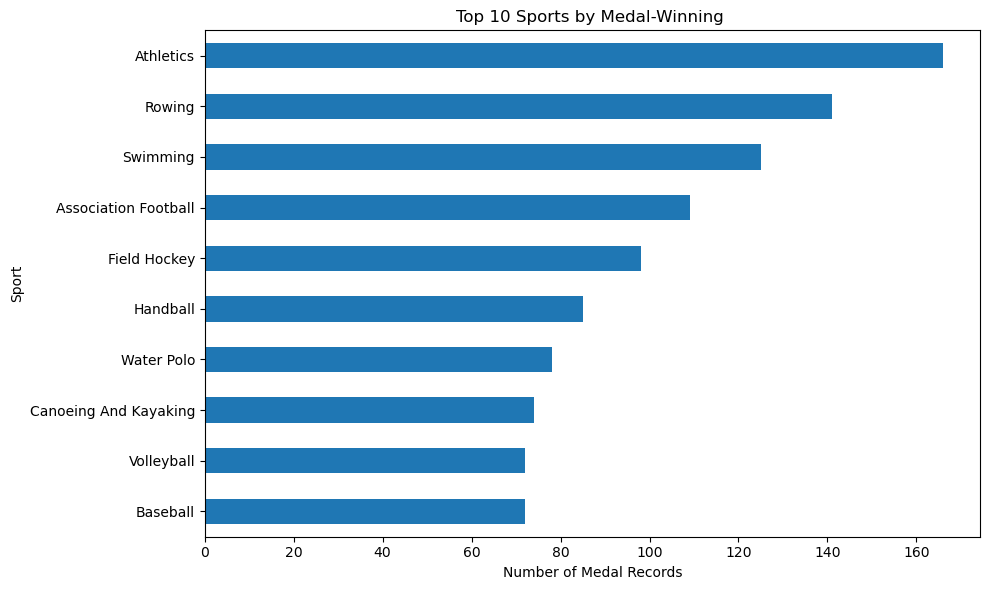

In [10]:
top_10_sports = tidy_df["sport"].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_10_sports.sort_values().plot(kind="barh")


plt.title("Top 10 Sports by Medal-Winning ")
plt.xlabel("Number of Medal Records")
plt.ylabel("Sport")
plt.tight_layout()
plt.show()


## 9. Visualization 2: Medal counts by gender

This visualization compares the total number of medal-winning observations for male and female categories.


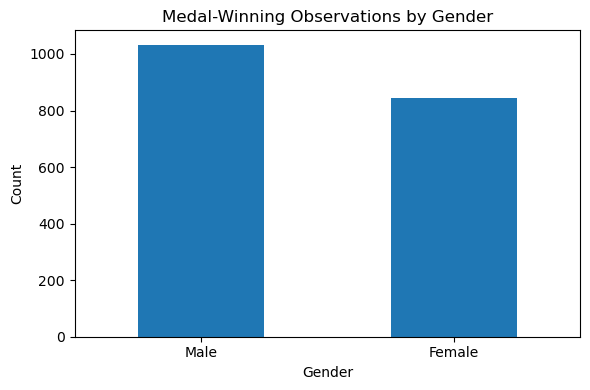

In [11]:
gender_counts = tidy_df["gender"].value_counts()

plt.figure(figsize=(6, 4))
gender_counts.plot(kind="bar")


plt.title("Medal-Winning Observations by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



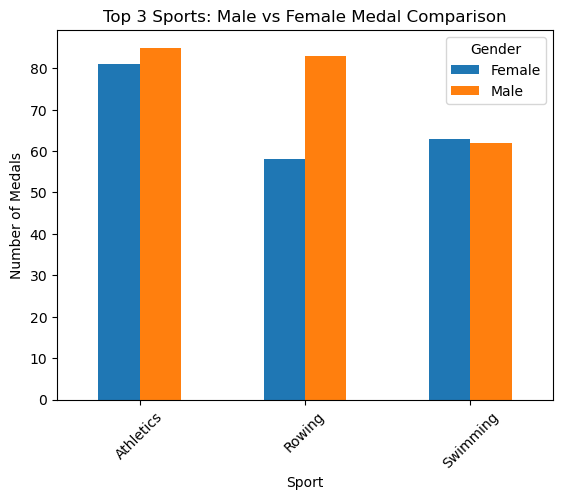

In [12]:
top_sports = tidy_df['sport'].value_counts().head(3).index
df_top = tidy_df[tidy_df['sport'].isin(top_sports)]
comparison = df_top.groupby(['sport', 'gender']).size().unstack()

comparison.plot(kind='bar')

plt.title('Top 3 Sports: Male vs Female Medal Comparison')
plt.xlabel('Sport')
plt.ylabel('Number of Medals')
plt.xticks(rotation=45)
plt.legend(title='Gender')

plt.show()




## 10. Summary

A grouped summary can also show how many medal records exist for each combination of gender and medal type.


In [13]:
gender_medal_summary = (
    tidy_df.groupby(["gender", "medal"])
    .size()
    .reset_index(name="count")
    .sort_values(["gender", "count"], ascending=[True, False])
)

display(gender_medal_summary)


,gender,medal,count
0,Female,Bronze,294
2,Female,Silver,278
1,Female,Gold,271
3,Male,Bronze,374
5,Male,Silver,343
4,Male,Gold,315


## Conclusion

By applying tidy data principles, I transformed a wide and difficult-to-analyze dataset into a clean table where:
- every variable has its own column,
- every observation has its own row,
- and the data is ready for aggregation and visualization.

This structure made it straightforward to:
- build a pivot table,
- compare medal counts across sports,
- and visualize patterns by sport and gender.

The tidy format is important because it makes analysis more consistent, more readable, and easier to extend for future work.
